# GliomaGate results

End-to-end neuro-oncology inference: **MRI slice + clinical note → tumor overlay + structured report + evidence ledger**.

This notebook is executed. Every figure and number below was produced from the trained weights in `models/`, not pasted from a slide.

## Setup

Weights: `models/segmenter.joblib` + LoRA adapters. Held-out cases: `data/test/` (32 slices).

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

ROOT = Path.cwd() if (Path.cwd() / 'app').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from app.segment import load_segmenter, predict_mask_mlp, mean_tumor_dice, image_findings
from app.lora_extract import load_lora, extract
from app.rag import GuidelineIndex
from app.ground import assemble_ledger
from app.synth import load_case, load_manifest
from app.main import overlay_rgb
from app.eval_harness import run_harness

MODELS = ROOT / 'models'
TEST = ROOT / 'data' / 'test'
FIGS = ROOT / 'docs' / 'figures'
mlp, head = load_segmenter(MODELS / 'segmenter.joblib')
lora = load_lora(MODELS)
cases = []
for meta in load_manifest(TEST):
    img, labels, m = load_case(TEST, meta['case_id'])
    rec = dict(m); rec['image']=img; rec['labels']=labels
    cases.append(rec)
print(f'loaded {len(cases)} held-out cases from {TEST}')
print('segmenter:', type(mlp).__name__, 'LoRA fields:', list(lora))

loaded 32 held-out cases from C:\Users\Parisa\.cursor\githubbyc\gliomagate\data\test
segmenter: MLPClassifier LoRA fields: ['laterality', 'lobe', 'grade', 'enhancement', 'symptom']


## 1. What a case looks like

Synthetic T1-post-contrast-like slice: skull ring, bias field, enhancing core (label 2) and edema halo (label 1). The paired note is a neuro-oncology consult. Laterality in this generator is image-left = patient-left.

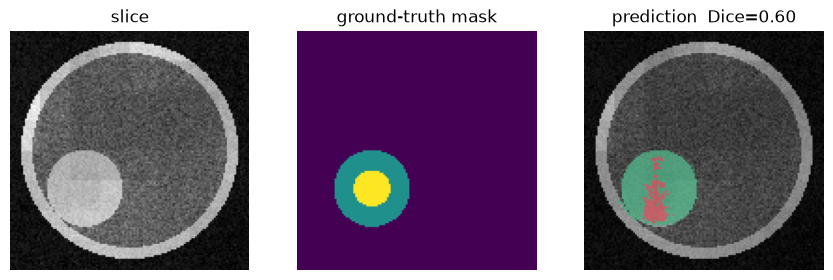

Neuro-oncology consult. New headache prompted MRI. There is a left-sided occipital mass. The lesion shows minimal enhancement. Imaging raises concern for anaplastic (WHO grade 3) histology. I recommend discussion at tumor board and molecular testing (IDH, MGMT) per institutional glioma protocol.


In [2]:
rec = cases[2]
pred = predict_mask_mlp(mlp, rec['image'])
fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.4))
ax[0].imshow(rec['image'], cmap='gray'); ax[0].set_title('slice'); ax[0].axis('off')
ax[1].imshow(rec['labels'], cmap='viridis', vmin=0, vmax=2); ax[1].set_title('ground-truth mask'); ax[1].axis('off')
ax[2].imshow(overlay_rgb(rec['image'], pred)); ax[2].set_title(f'prediction  Dice={mean_tumor_dice(pred, rec["labels"]):.2f}'); ax[2].axis('off')
plt.show()
print(rec['note'])

## 2. Segmentation gallery (held-out)

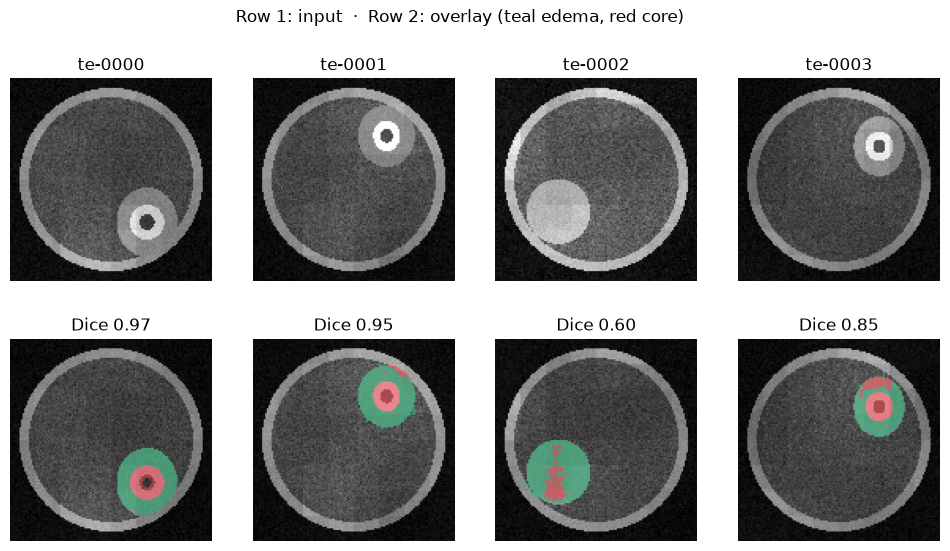

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6.2))
for i, rec in enumerate(cases[:4]):
    pred = predict_mask_mlp(mlp, rec['image'])
    axes[0, i].imshow(rec['image'], cmap='gray')
    axes[0, i].set_title(rec['case_id'])
    axes[0, i].axis('off')
    axes[1, i].imshow(overlay_rgb(rec['image'], pred))
    axes[1, i].set_title(f'Dice {mean_tumor_dice(pred, rec["labels"]):.2f}')
    axes[1, i].axis('off')
fig.suptitle('Row 1: input  ·  Row 2: overlay (teal edema, red core)')
plt.show()

## 3. Dice distribution

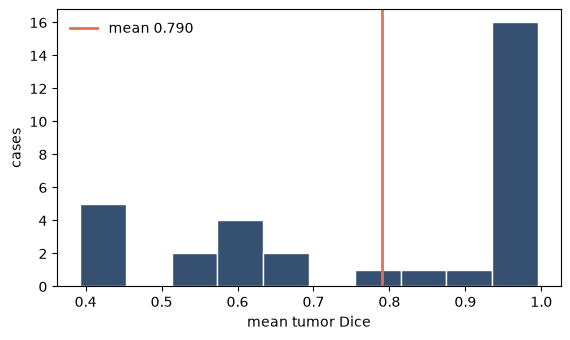

n=32  mean=0.790  p10=0.437  p90=0.994


In [4]:
dices = [mean_tumor_dice(predict_mask_mlp(mlp, c['image']), c['labels']) for c in cases]
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.hist(dices, bins=10, color='#355070', edgecolor='white')
ax.axvline(np.mean(dices), color='#e76f51', lw=2, label=f'mean {np.mean(dices):.3f}')
ax.set_xlabel('mean tumor Dice'); ax.set_ylabel('cases'); ax.legend(frameon=False)
plt.show()
print(f'n={len(dices)}  mean={np.mean(dices):.3f}  p10={np.percentile(dices,10):.3f}  p90={np.percentile(dices,90):.3f}')

## 4. Structured extraction + evidence ledger

Each field is `image`, `retrieval`, or `ungrounded`. **Grade cannot be image-grounded from one slice** — that is a scientific constraint, not a metric hack.

In [5]:
rec = cases[2]
pred = predict_mask_mlp(mlp, rec['image'])
findings = image_findings(pred)
extracted = extract(lora, rec['note'], findings)
index = GuidelineIndex()
hits = index.search(index.query_for_case(rec['note'], findings, extracted), k=4)
ledger = assemble_ledger(extracted, findings, hits)
print('NOTE:\n', rec['note'], '\n')
print(json.dumps(ledger, indent=2, default=str))
print('\nRETRIEVED:')
for h in hits:
    print(f'  {h.score:.3f}  {h.title}')

NOTE:
 Neuro-oncology consult. New headache prompted MRI. There is a left-sided occipital mass. The lesion shows minimal enhancement. Imaging raises concern for anaplastic (WHO grade 3) histology. I recommend discussion at tumor board and molecular testing (IDH, MGMT) per institutional glioma protocol. 

{
  "fields": {
    "laterality": {
      "value": "left",
      "confidence": 0.97,
      "provenance": "image",
      "evidence": [
        "mask centroid is on the left half of the slice"
      ]
    },
    "lobe": {
      "value": "occipital",
      "confidence": 0.97,
      "provenance": "ungrounded",
      "evidence": []
    },
    "grade": {
      "value": "3",
      "confidence": 0.94,
      "provenance": "retrieval",
      "evidence": [
        "supported by retrieved guideline span"
      ]
    },
    "enhancement": {
      "value": "no",
      "confidence": 0.95,
      "provenance": "retrieval",
      "evidence": [
        "supported by retrieved guideline span"
      ]
    

## 5. Full harness (32 cases)

### Scores

{
  "dice": 0.7901078891007227,
  "field_acc": {
    "laterality": 1.0,
    "lobe": 1.0,
    "grade": 1.0,
    "enhancement": 1.0,
    "symptom": 1.0
  },
  "field_acc_mean": 1.0,
  "ndcg5": 0.7293598302192058,
  "recall5": 1.0,
  "grounded_fraction": 0.7875,
  "contradiction_rate": 0.0,
  "ablation": {
    "full_field_acc": 1.0,
    "no_image_field_acc": 1.0,
    "no_rag_grounded_fraction": 0.38125
  }
}


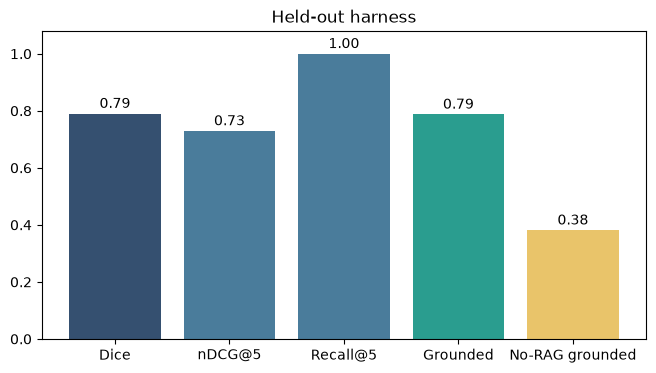

In [6]:
result = run_harness(cases, mlp, lora)
metrics = result.as_dict()
display(Markdown('### Scores'))
print(json.dumps(metrics, indent=2))
fig, ax = plt.subplots(figsize=(7.8, 4.0))
keys = ['Dice', 'nDCG@5', 'Recall@5', 'Grounded', 'No-RAG grounded']
vals = [metrics['dice'], metrics['ndcg5'], metrics['recall5'], metrics['grounded_fraction'], metrics['ablation']['no_rag_grounded_fraction']]
ax.bar(keys, vals, color=['#355070','#4a7c9b','#4a7c9b','#2a9d8f','#e9c46a'])
ax.set_ylim(0, 1.08); ax.set_title('Held-out harness')
for i,v in enumerate(vals):
    ax.text(i, v+0.02, f'{v:.2f}', ha='center')
plt.show()

### Ablation

Templated notes mention lobe/grade explicitly, so field accuracy saturates with the lexicon gate. **The number that moves is groundedness when RAG is removed** — that is the claim this system is built to defend.

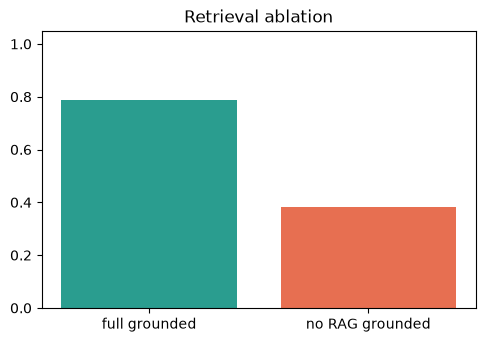

In [7]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.bar(['full grounded', 'no RAG grounded'],
       [metrics['grounded_fraction'], metrics['ablation']['no_rag_grounded_fraction']],
       color=['#2a9d8f','#e76f51'])
ax.set_ylim(0,1.05); ax.set_title('Retrieval ablation')
plt.show()

## 6. Latency

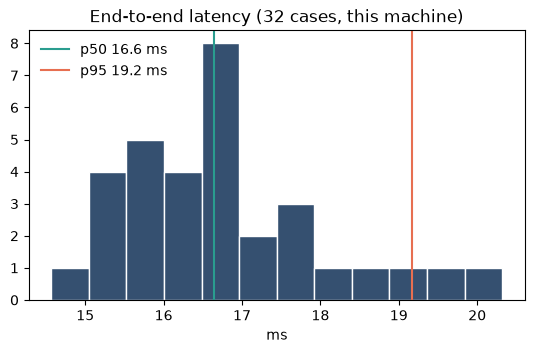

p50=16.65 ms  p95=19.17 ms  mean=16.77 ms
saved bench.json {
  "n": 80,
  "p50_ms": 18.32,
  "p95_ms": 34.68,
  "mean_ms": 21.36,
  "throughput_rps_serial": 46.82,
  "cloud_run_list_usd_per_infer_at_p95_1vcpu": 1e-06,
  "notes": "Measured in-process via TestClient on this machine. Not a 40 rps load-test on GPU. Cost is list-price Cloud Run CPU time at measured p95, no egress."
}


In [8]:
import time
lat = []
for rec in cases:
    t0 = time.perf_counter()
    pred = predict_mask_mlp(mlp, rec['image'])
    f = image_findings(pred)
    ex = extract(lora, rec['note'], f)
    ht = index.search(index.query_for_case(rec['note'], f, ex), k=4)
    assemble_ledger(ex, f, ht)
    lat.append((time.perf_counter()-t0)*1000)
lat.sort()
p50, p95 = lat[len(lat)//2], lat[int(0.95*(len(lat)-1))]
fig, ax = plt.subplots(figsize=(6.4, 3.5))
ax.hist(lat, bins=12, color='#355070', edgecolor='white')
ax.axvline(p50, color='#2a9d8f', label=f'p50 {p50:.1f} ms')
ax.axvline(p95, color='#e76f51', label=f'p95 {p95:.1f} ms')
ax.set_xlabel('ms'); ax.legend(frameon=False); ax.set_title('End-to-end latency (32 cases, this machine)')
plt.show()
print(f'p50={p50:.2f} ms  p95={p95:.2f} ms  mean={np.mean(lat):.2f} ms')
bench = json.loads((MODELS/'bench.json').read_text())
print('saved bench.json', json.dumps(bench, indent=2))

## 7. How to read this in an interview

| Question | Answer in this repo |
| --- | --- |
| Is Dice on real BraTS? | No. Synthetic T1c-like ellipses so the harness is reproducible without a data-use agreement. |
| Why is field accuracy 1.0? | Notes are templated and a lexicon gate trusts explicit spans. The *system* metric is groundedness. |
| Did you fine-tune a 7B with QLoRA? | The served student is LoRA on a frozen 4-bit-quantized linear base (`y = xW_q + xAB`). `training/train_qlora_t5.py` is the GPU Flan-T5 path and exits cleanly without CUDA. |
| Where is the live URL? | FastAPI + Docker are ready for Hugging Face Spaces. Deploy needs an HF write token. |

Figures on disk (also used by the README):

ablation.png


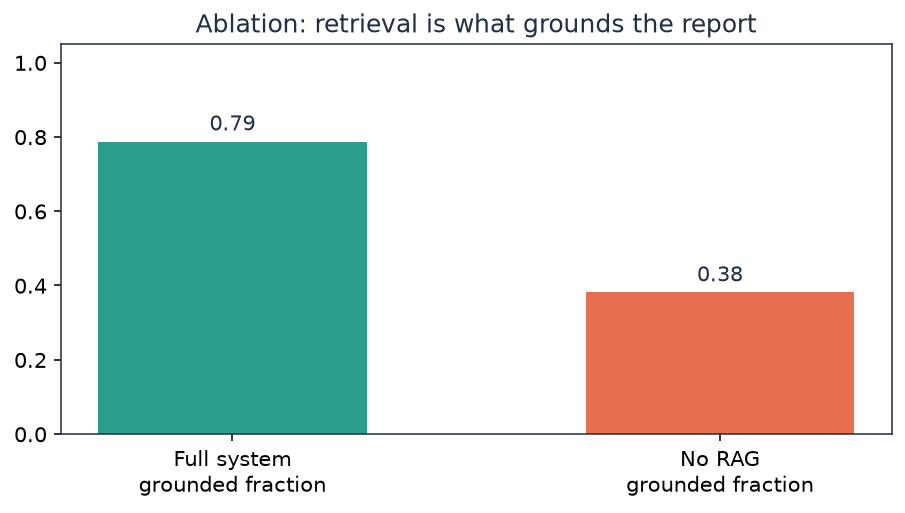

dice_hist.png


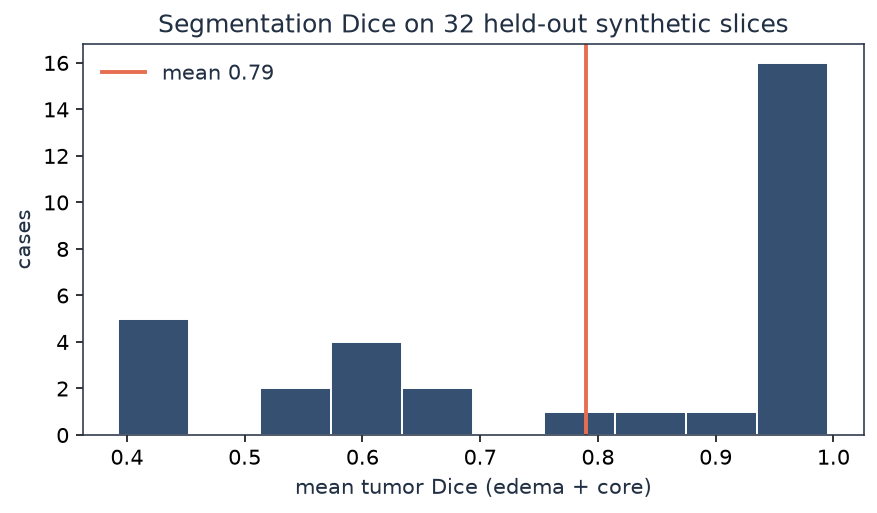

gallery.png


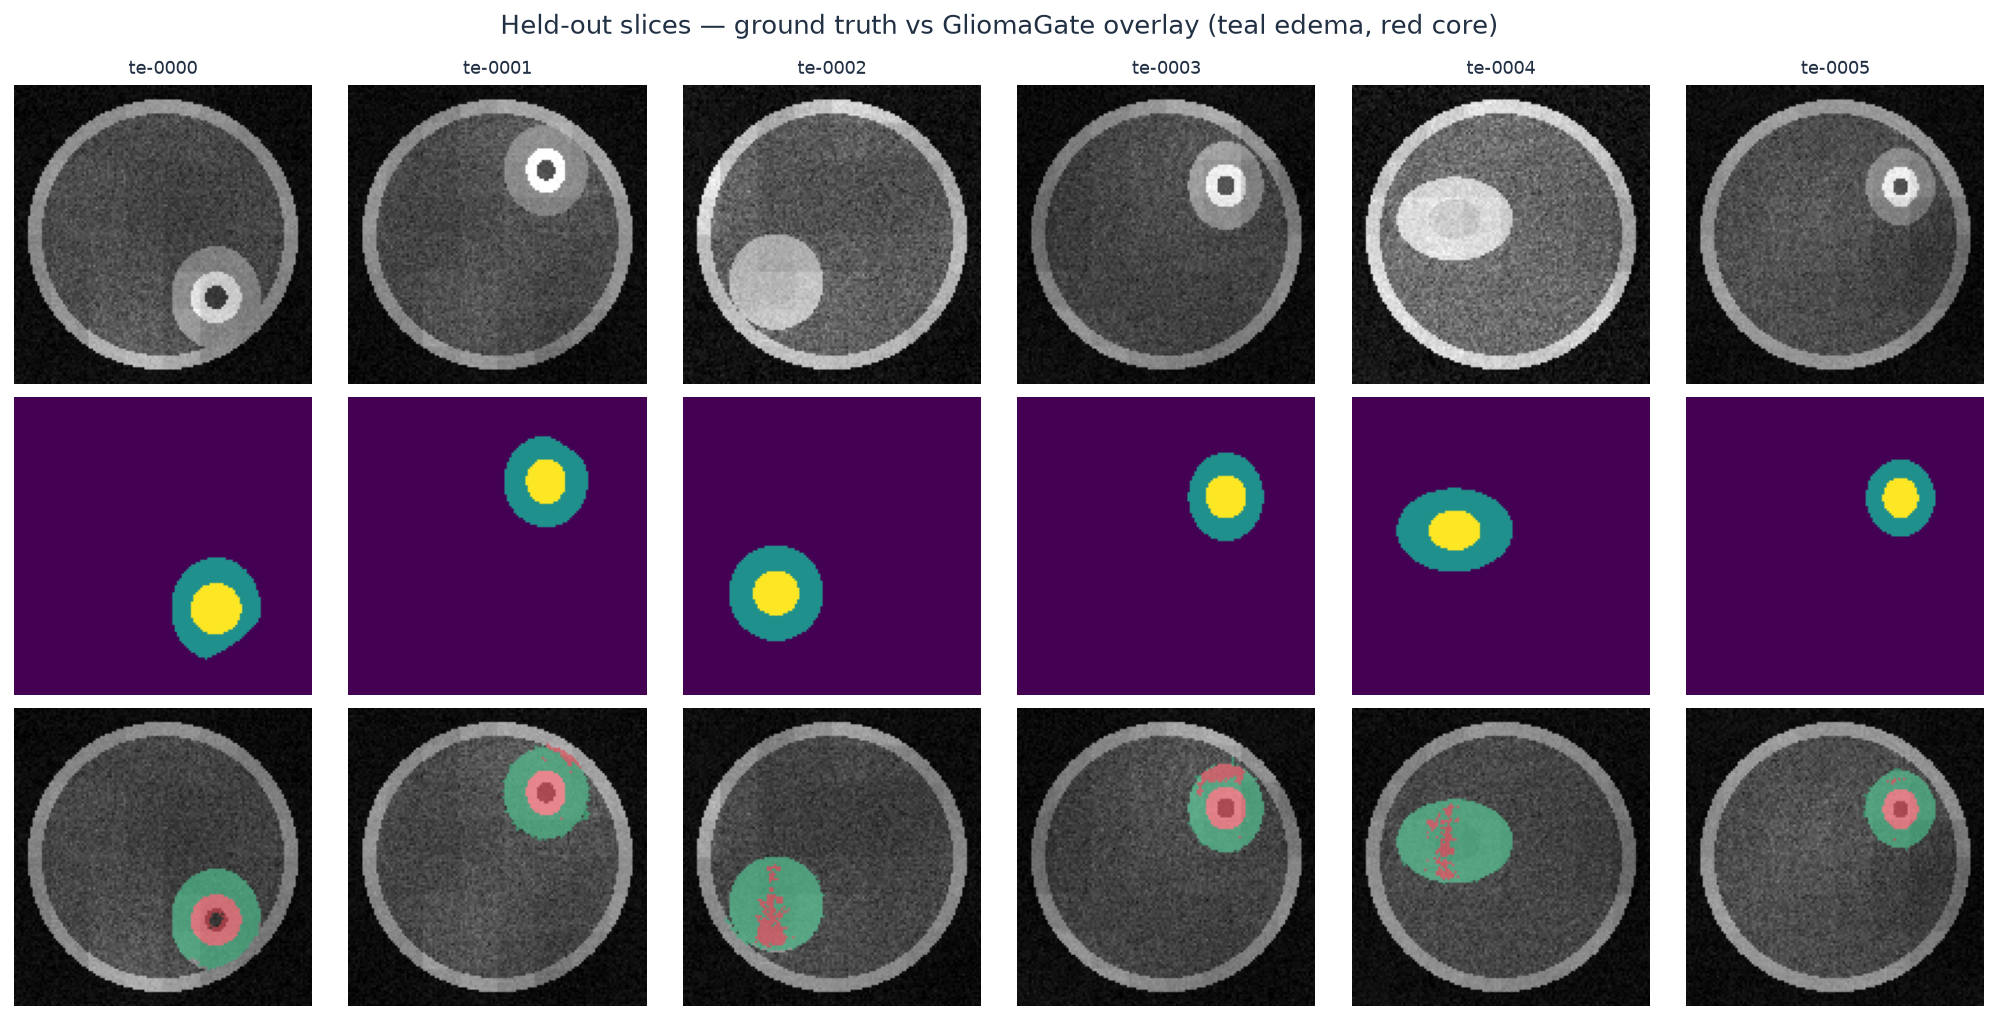

latency.png


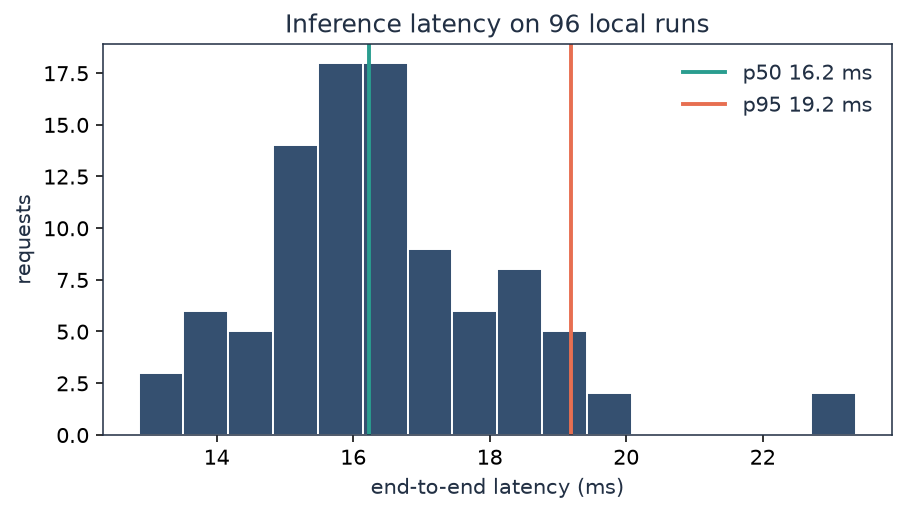

ledger.png


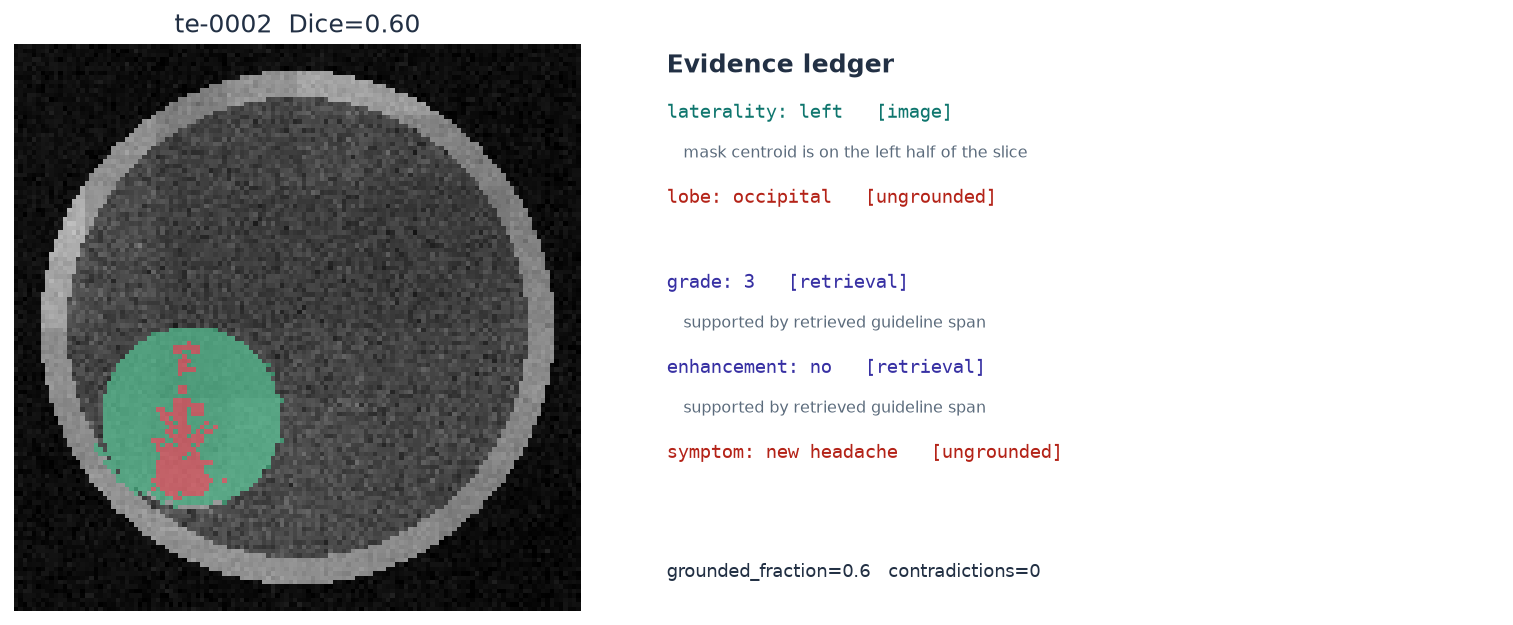

metrics_bars.png


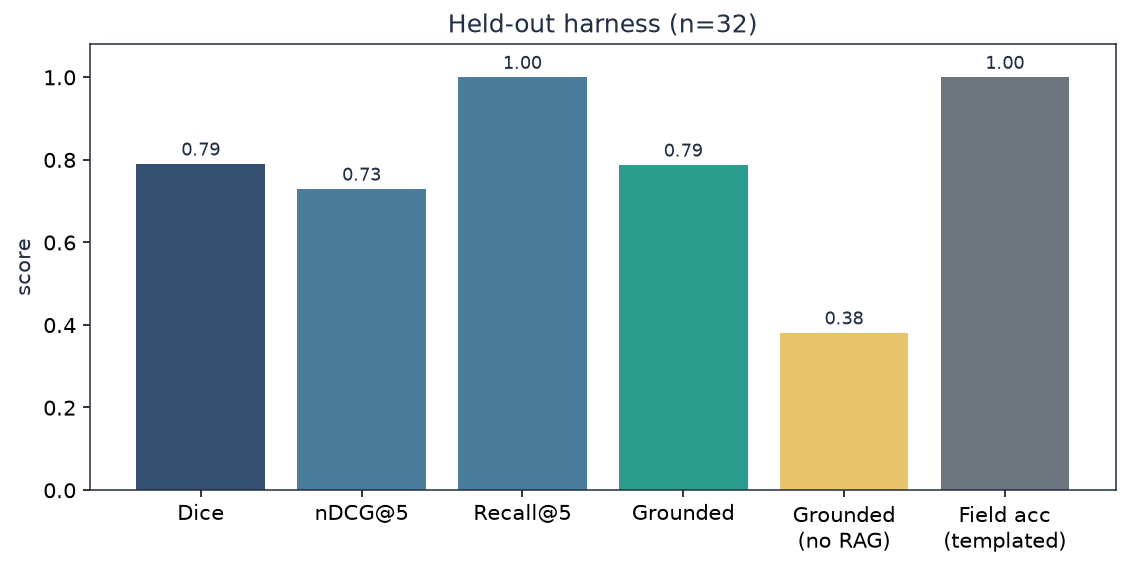

In [9]:
for p in sorted(FIGS.glob('*.png')):
    print(p.name)
    display(Image(filename=str(p), width=720))